# Sandra Otubushin Notebook
# P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Sandra Otubushin](https://github.com/larrygold18/)
- Repository: [nlp-03-text-exploration](https://github.com/larrygold18/nlp-03-text-exploration/)
- Date: 2026-03

Purpose

  Perform exploratory analysis of a small, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

This is a Markdown cell.

## Section 0. Intro to Jupyter Notebooks

This is a Markdown cell.

Tips:
- Run a cell with Ctrl+Enter (Cmd+Enter on Mac)
- Select a kernel (your .venv)
- Use Run All before committing

TODO: Delete or customize this section.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

This is a Markdown cell.

In [12]:
# Section 1 Python cell

from collections import defaultdict
import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

This is a Markdown cell.

In [13]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-25 12:11:20 | INFO | CI | === RUN START ===
2026-03-25 12:11:20 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-25 12:11:20 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-25 12:11:20 | INFO | CI | python=3.14.3
2026-03-25 12:11:20 | INFO | CI | os=Windows 11
2026-03-25 12:11:20 | INFO | CI | shell=powershell
2026-03-25 12:11:20 | INFO | CI | cwd=notebooks
2026-03-25 12:11:20 | INFO | CI | github_actions=False
2026-03-25 12:11:20 | INFO | CI | ROOT_PATH = .
2026-03-25 12:11:20 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-25 12:11:20 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-25 12:11:20 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

This is a Markdown cell.

In [14]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus = [
    {"category": "dog", "text": "A dog barks loudly."},
    {"category": "dog", "text": "The puppy runs in the yard."},
    {"category": "dog", "text": "A canine wears a leash."},
    {"category": "dog", "text": "The dog ran across the yard."},
    {"category": "cat", "text": "A cat sleeps quietly."},
    {"category": "cat", "text": "The kitten plays with yarn."},
    {"category": "cat", "text": "A feline purrs softly."},
    {"category": "cat", "text": "The cat slept near the window."},
    {"category": "car", "text": "A car drives on the road."},
    {"category": "car", "text": "The sedan parks in the garage."},
    {"category": "car", "text": "A vehicle has four wheels."},
    {"category": "truck", "text": "A truck carries cargo."},
    {"category": "truck", "text": "The pickup pulls a trailer."},
    {"category": "truck", "text": "The truck hauls heavy loads."},
    {"category": "dog", "text": "The dog chased the ball in the park."},
    {"category": "dog", "text": "A puppy chewed on the toy."},
]

print(f"Corpus contains {len(corpus)} documents.")

if not corpus:
    raise ValueError("Corpus is empty. Add documents before running analysis.")

categories = {doc["category"] for doc in corpus}
print(f"Categories in corpus: {sorted(categories)}")

Corpus contains 16 documents.
Categories in corpus: ['car', 'cat', 'dog', 'truck']


## Section 3. Tokenize and Clean Text

This is a Markdown cell.

In [15]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

# Define a function to tokenize text by lowercasing, splitting on whitespace,
# and stripping common punctuation. We also filter out very short tokens (length <= 2).
# This simple tokenizer is sufficient for our small, controlled corpus.
# Use the string strip() method to remove punctuation from the beginning and end of each token.
STOP_WORDS = {"the", "and", "has", "with", "for", "are", "was", "in", "on", "a"}


def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [
        t.strip(".,:;!?()[]\"'")
        for t in tokens
        if len(t) > 2 and t.strip(".,:;!?()[]\"'") not in STOP_WORDS
    ]


# Define a new empty list to hold the token records we will create.
records_list: list[dict[str, str]] = []
# Loop through each document, tokenize the text,
# and create a record for each token with its category and
# add it to our list of records.
for doc in corpus:
    # Call our function to tokenize the text of the current document.
    tokens = tokenize(doc["text"])
    # Loop through each token produced by the tokenizer and
    # create a record that includes the category of the document and the token itself.
    # Append this record to our list of records.
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create a Polars DataFrame from the list of token records for easier analysis.
token_df: pl.DataFrame = pl.DataFrame(records_list)

# Show results
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬────────┐
│ category ┆ token  │
│ ---      ┆ ---    │
│ str      ┆ str    │
╞══════════╪════════╡
│ dog      ┆ dog    │
│ dog      ┆ barks  │
│ dog      ┆ loudly │
│ dog      ┆ puppy  │
│ dog      ┆ runs   │
│ dog      ┆ yard   │
│ dog      ┆ canine │
│ dog      ┆ wears  │
│ dog      ┆ leash  │
│ dog      ┆ dog    │
└──────────┴────────┘


## Section 4. Compute Global Token Frequencies

This is a Markdown cell.

In [16]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

# Create a DataFrame that groups the tokens by their text and
# counts how many times each token appears across the entire corpus.
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)

unique_token_count: int = global_freq_df.height
print(f"Unique token count across corpus: {unique_token_count}")

# Show results
print("Top global tokens:")
print(global_freq_df.head(10))

Unique token count across corpus: 46
Top global tokens:
shape: (10, 2)
┌────────┬─────┐
│ token  ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ dog    ┆ 3   │
│ puppy  ┆ 2   │
│ yard   ┆ 2   │
│ cat    ┆ 2   │
│ truck  ┆ 2   │
│ car    ┆ 1   │
│ feline ┆ 1   │
│ leash  ┆ 1   │
│ kitten ┆ 1   │
│ loads  ┆ 1   │
└────────┴─────┘


## Section 5. Compute Token Frequencies by Category

This is a Markdown cell.

In [17]:
# Section 5 Python cell

# Compare token usage across categories.

# Create a new DataFrame that groups the tokens by both their category and text,
# counts how many times each token appears within each category,
# and sorts the results first by category and then by frequency in descending order.
# This shows which tokens are most common within each category.
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

# Show results
print("Top tokens by category:")
print(category_freq_df.head(12))

Top tokens by category:
shape: (12, 3)
┌──────────┬─────────┬─────┐
│ category ┆ token   ┆ len │
│ ---      ┆ ---     ┆ --- │
│ str      ┆ str     ┆ u32 │
╞══════════╪═════════╪═════╡
│ truck    ┆ truck   ┆ 2   │
│ truck    ┆ pulls   ┆ 1   │
│ truck    ┆ cargo   ┆ 1   │
│ truck    ┆ carries ┆ 1   │
│ truck    ┆ pickup  ┆ 1   │
│ …        ┆ …       ┆ …   │
│ truck    ┆ hauls   ┆ 1   │
│ truck    ┆ loads   ┆ 1   │
│ dog      ┆ dog     ┆ 3   │
│ dog      ┆ puppy   ┆ 2   │
│ dog      ┆ yard    ┆ 2   │
└──────────┴─────────┴─────┘


## Section 6. Identify Top Tokens per Category

This is a Markdown cell.

In [18]:
# Section 6 Python cell

# Show top tokens per category.


# Define a new empty dictionary to store the top tokens for each category.
top_per_category_dict: dict[str, list[str]] = {}

# Loop through each unique category in the token DataFrame,
# filter the category frequency DataFrame to get the top 5 tokens for that category,
# and store the list of top tokens in the dictionary.
# Also, print the top tokens for each category.
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    # Show results for this category
    print(f"{category.upper()} top tokens: {top_tokens_list}")

CAT top tokens: ['cat', 'sleeps', 'softly', 'quietly', 'feline']
DOG top tokens: ['dog', 'puppy', 'yard', 'across', 'ball']
CAR top tokens: ['parks', 'four', 'sedan', 'garage', 'car']
TRUCK top tokens: ['truck', 'pulls', 'cargo', 'carries', 'pickup']


## Section 7. Analyze Co-occurrence (Context Windows)

This is a Markdown cell.

In [19]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

# Define how many tokens on each side of a target token we include as context.
# A window size of 3 means:
#   - up to 3 tokens before the target token
#   - up to 3 tokens after the target token
# The target token itself is not included in its context list.
WINDOW_SIZE: int = 3

# Define a new empty dictionary to store the co-occurrence information.
# The keys will be target tokens,
# and the values will be lists of context tokens that appear near the target token.
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

# Loop through each document in the corpus, tokenize the text,
# and for each token, determine its context tokens based on the defined window size.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

# Show results
for target in ["dog", "cat", "car", "truck"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'dog':
['barks', 'loudly', 'ran', 'across', 'yard', 'chased', 'ball', 'park']

Context for 'cat':
['sleeps', 'quietly', 'slept', 'near', 'window']

Context for 'car':
['drives', 'road']

Context for 'truck':
['carries', 'cargo', 'hauls', 'heavy', 'loads']


## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

This is a Markdown cell.

In [20]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

# Bigrams capture pairs of consecutive tokens.

# Define a new empty list to hold the bigram tuples we will create.
bigrams_list: list[tuple[str, str]] = []

# Loop through each document in the corpus, tokenize the text,
# and create bigrams by pairing each token with the next token in the list.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

# Create a DataFrame from the list of bigram tuples,
# where each bigram is represented as a single string with the two tokens separated by a space.
bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)

# Create a new DataFrame that groups the bigrams by their text
# and counts how many times each bigram appears,
# then sorts the results by frequency in descending order.
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

# Show results
print("Top bigrams:")
print(bigram_freq_df.head(10))

Top bigrams:
shape: (10, 2)
┌────────────────┬─────┐
│ bigram         ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ near window    ┆ 1   │
│ truck carries  ┆ 1   │
│ barks loudly   ┆ 1   │
│ kitten plays   ┆ 1   │
│ sleeps quietly ┆ 1   │
│ parks garage   ┆ 1   │
│ pickup pulls   ┆ 1   │
│ four wheels    ┆ 1   │
│ dog barks      ┆ 1   │
│ wears leash    ┆ 1   │
└────────────────┴─────┘


## Section 9. Visualize Token Frequencies

This is a Markdown cell.



IMPORTANT: Close chart window to continue execution.


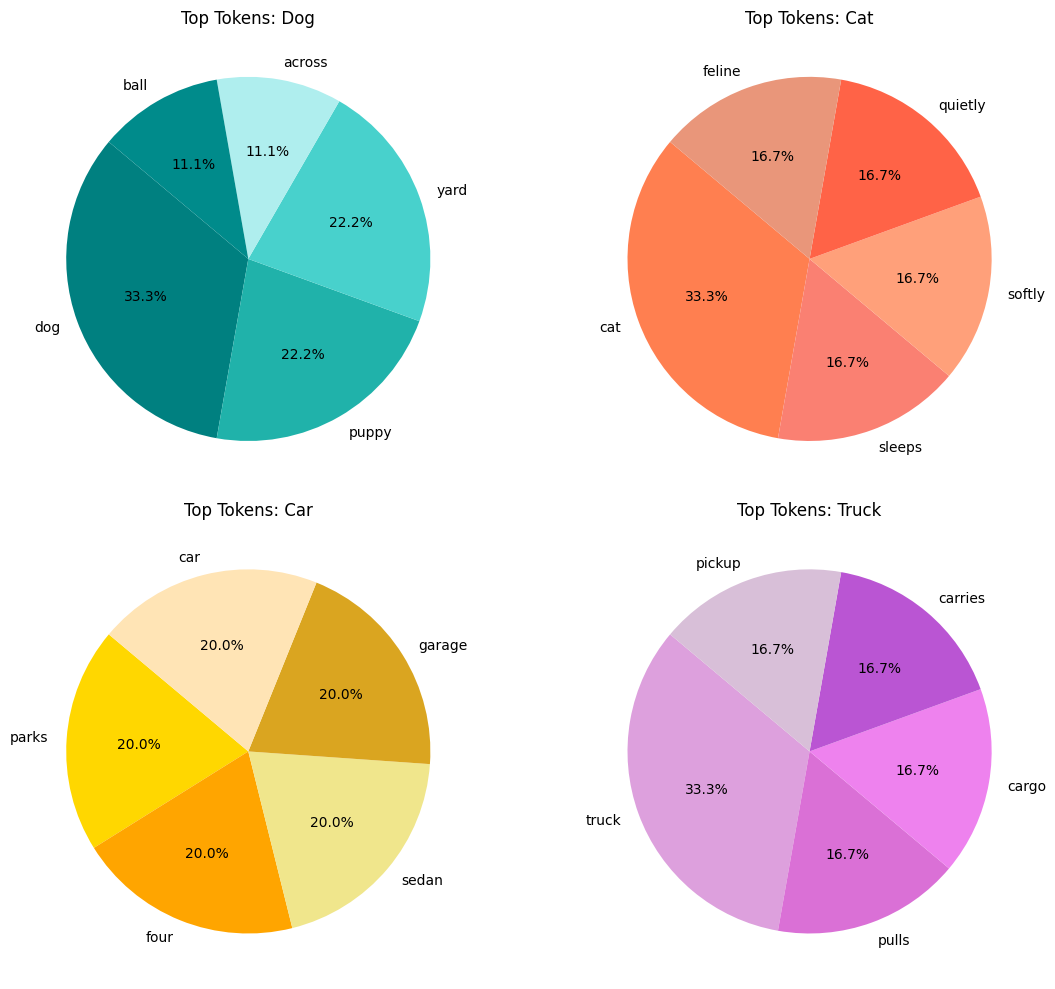

In [21]:
# Section 9 Python cell
# ============================================================
# Section 9. Visualize Token Frequencies by Category
# ============================================================

print("IMPORTANT: Close chart window to continue execution.")

categories = ["dog", "cat", "car", "truck"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

color_sets = [
    ["teal", "lightseagreen", "mediumturquoise", "paleturquoise", "darkcyan"],
    ["coral", "salmon", "lightsalmon", "tomato", "darksalmon"],
    ["gold", "orange", "khaki", "goldenrod", "moccasin"],
    ["plum", "orchid", "violet", "mediumorchid", "thistle"],
]

for i, category in enumerate(categories):
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)

    axes[i].pie(
        subset_df["len"],
        labels=subset_df["token"],
        autopct="%1.1f%%",
        startangle=140,
        colors=color_sets[i],
    )
    axes[i].set_title(f"Top Tokens: {category.title()}")

plt.tight_layout()
plt.show()

## Section 10. Interpret Results and Identify Patterns

This is a Markdown cell.

In [22]:
# Section 10 Python cell


print("\nCASE GENERAL OBSERVATIONS:")

print("- Tokens cluster by category (dog, cat, car, truck).")
print("- Words that appear in similar contexts behave similarly.")
print("- Co-occurrence reveals contextual relationships between words.")
print("- Bigrams capture local structure beyond single tokens.")
print("- Patterns emerge before any machine learning is applied.")

print("\nSANDRA SPECIFIC OBSERVATIONS:")
print(
    "- The pie charts make it easier to compare dominant tokens within each category."
)
print(
    "- Dog and cat categories show animal-related vocabulary, while car and truck show vehicle-related vocabulary."
)
print(
    "- The distribution of top tokens differs across categories, showing that each group has a distinct vocabulary pattern."
)
print(
    "- Pie charts highlight proportion, which helps show how strongly certain tokens dominate each category."
)
print(
    "- Comparing categories side by side makes it easier to see which tokens are unique to one topic and which patterns are shared."
)


CASE GENERAL OBSERVATIONS:
- Tokens cluster by category (dog, cat, car, truck).
- Words that appear in similar contexts behave similarly.
- Co-occurrence reveals contextual relationships between words.
- Bigrams capture local structure beyond single tokens.
- Patterns emerge before any machine learning is applied.

SANDRA SPECIFIC OBSERVATIONS:
- The pie charts make it easier to compare dominant tokens within each category.
- Dog and cat categories show animal-related vocabulary, while car and truck show vehicle-related vocabulary.
- The distribution of top tokens differs across categories, showing that each group has a distinct vocabulary pattern.
- Pie charts highlight proportion, which helps show how strongly certain tokens dominate each category.
- Comparing categories side by side makes it easier to see which tokens are unique to one topic and which patterns are shared.
